# Tutorial — Esteira de EDA de Features (`yggdrasil.eda`)

Análise exploratória de **features** (não do modelo): missing, percentis, histograma, relação com o
alvo, binning (WoE/IV), importância, estabilidade (PSI) e um relatório consolidado com **veredito por
feature** (manter/revisar/descartar). É um subpacote **isolado** — não interfere na esteira de modelo.

> Contrato igual ao resto do pacote: features `feat_`, `dt_ref`, `amostra` (DES/OOT + scoring-only) e
> `target` (opcional na EDA).

## 0. Setup + dataset sintético

In [1]:
import os
import numpy as np
import pandas as pd

os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
rng = np.random.default_rng(0)

# Dataset com features de comportamentos variados (para a EDA "pegar" cada caso).
n = 5000
meses = pd.date_range("2023-01-01", periods=12, freq="MS")
df = pd.DataFrame({
    "feat_bom":      rng.normal(size=n),                       # forte preditora
    "feat_fraca":    rng.normal(size=n),                       # sem sinal
    "feat_cat":      rng.choice(["A", "B", "C", "D"], size=n, p=[.5, .3, .15, .05]),
    "feat_const":    1.0,                                      # constante
    "feat_instavel": rng.normal(size=n),                       # vai sofrer drift
    "feat_missing":  rng.normal(size=n),                       # vai ter muito missing
})
df["target"] = (df["feat_bom"] * 1.2 + rng.normal(0, 0.6, n) > 0).astype(int)
df["feat_leakage"] = df["target"] + rng.normal(0, 0.01, n)    # vazamento óbvio
df["dt_ref"] = rng.choice(meses, size=n)
df["amostra"] = np.where(df["dt_ref"] >= meses[8], "OOT", "DES")
df.loc[df["amostra"] == "OOT", "feat_instavel"] += 2.5         # drift no OOT
df.loc[df.sample(frac=0.6, random_state=2).index, "feat_missing"] = np.nan
df.loc[df.sample(frac=0.04, random_state=3).index, "amostra"] = "SIMUL"
df.head()

,feat_bom,feat_fraca,feat_cat,feat_const,feat_instavel,feat_missing,target,feat_leakage,dt_ref,amostra
0,0.1257,-0.1800,B,1.0000,-1.1466,0.1217,1,1.0090,2023-01-01,DES
1,-0.1321,1.8087,A,1.0000,-0.1378,-0.5946,0,0.0041,2023-06-01,DES
2,0.6404,0.3450,A,1.0000,1.4628,NaN,1,0.9839,2023-11-01,OOT
3,0.1049,-0.6964,A,1.0000,2.5444,NaN,1,0.9990,2023-12-01,OOT
4,-0.5357,0.4768,D,1.0000,1.6222,NaN,0,0.0064,2023-05-01,DES


## 1. Configuração

`ColumnConfig` (nomes de colunas) + `EDAConfig` (parâmetros da EDA). Sentinelas (-1/-999/'NULL'…) são
**opt-in**: por padrão só NaN conta como missing. Para ligá-las: `EDAConfig(missing_codes=DEFAULT_MISSING_CODES)`.

In [2]:
from yggdrasil import ColumnConfig
from yggdrasil.eda import EDAConfig
from yggdrasil.eda import profile

cfg, ec = ColumnConfig(), EDAConfig()
profile.dataset_overview(df, cfg, ec)

{'n_linhas': 5000,
 'n_features': 7,
 'n_numericas': 6,
 'n_categoricas': 1,
 'periodo_min': '2023-01-01',
 'periodo_max': '2023-12-01',
 'amostras': {'DES': 3207, 'OOT': 1593, 'SIMUL': 200},
 'tem_target': True,
 'n_duplicadas': 0,
 'problem_type': 'classification',
 'event_rate': 0.4902}

## 2. Missing (item 1 e 2)

In [3]:
print("Missing global por feature:")
display(profile.missing_summary(df, cfg, ec))

Missing global por feature:


,feature,tipo,n,n_missing,pct_missing,pct_zero,pct_missing_dev,pct_missing_oot,flag
0,feat_bom,numeric,5000,0,0.0000,0.0000,0.0000,0.0000,ok
1,feat_fraca,numeric,5000,0,0.0000,0.0000,0.0000,0.0000,ok
2,feat_cat,categorical,5000,0,0.0000,NaN,0.0000,0.0000,ok
3,feat_const,binary,5000,0,0.0000,0.0000,0.0000,0.0000,ok
4,feat_instavel,numeric,5000,0,0.0000,0.0000,0.0000,0.0000,ok
5,feat_missing,numeric,5000,3000,0.6000,0.0000,0.6056,0.5895,descartar
6,feat_leakage,numeric,5000,0,0.0000,0.0000,0.0000,0.0000,ok


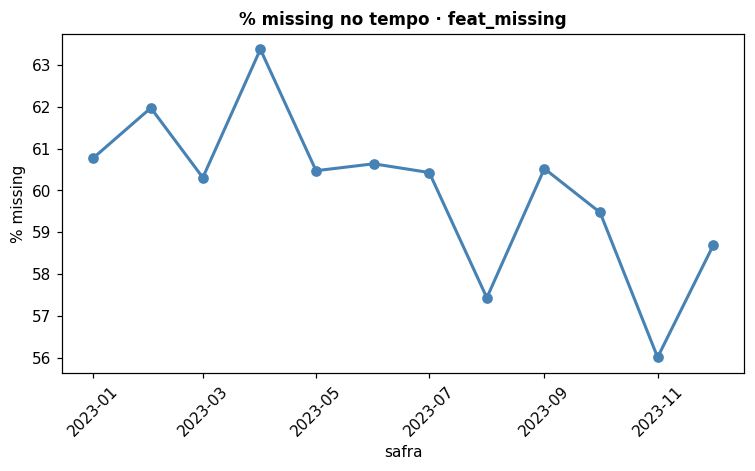

In [4]:
from yggdrasil.eda.plots import plot_missing_over_time
# feat_missing tem 60% de ausência
plot_missing_over_time(df, "feat_missing", cfg, ec)

## 3. Percentis e distribuição (itens 3 e 4)

In [5]:
print("Percentis (GERAL + por amostra):")
display(profile.percentile_table(df, "feat_bom", cfg, ec))

Percentis (GERAL + por amostra):


,p01,p05,p10,p25,p50,p75,p90,p95,p99,mean,std,min,max,skew,kurtosis,iqr
GERAL,-2.2503,-1.6219,-1.2562,-0.6848,-0.0277,0.6783,1.2938,1.6479,2.2857,-0.0045,0.9955,-3.8994,3.2572,0.0192,-0.0996,1.3631
DES,-2.2499,-1.6004,-1.2580,-0.6932,-0.0352,0.6801,1.2837,1.6487,2.3057,-0.0085,0.9986,-3.8994,3.2572,0.0168,-0.0673,1.3733
OOT,-2.2092,-1.6163,-1.2415,-0.6602,-0.0129,0.6801,1.3206,1.6509,2.2221,0.0107,0.9835,-3.1145,2.8412,0.0269,-0.2157,1.3403


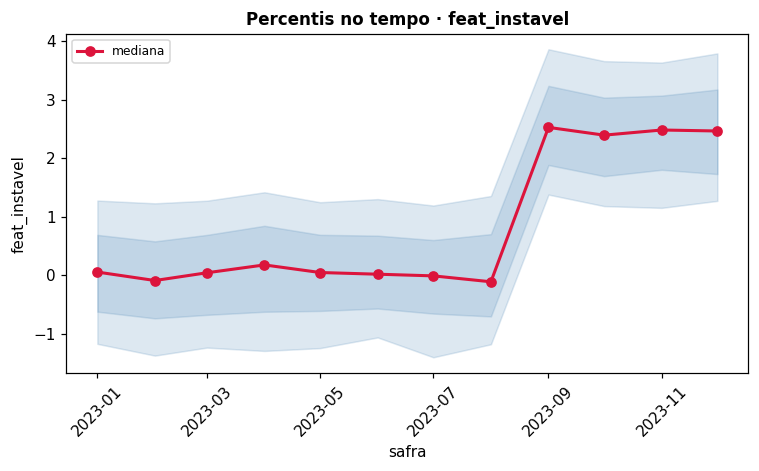

In [6]:
from yggdrasil.eda.plots import plot_percentile_fan, plot_histogram
plot_percentile_fan(df, "feat_instavel", cfg, ec)   # drift de localização no tempo

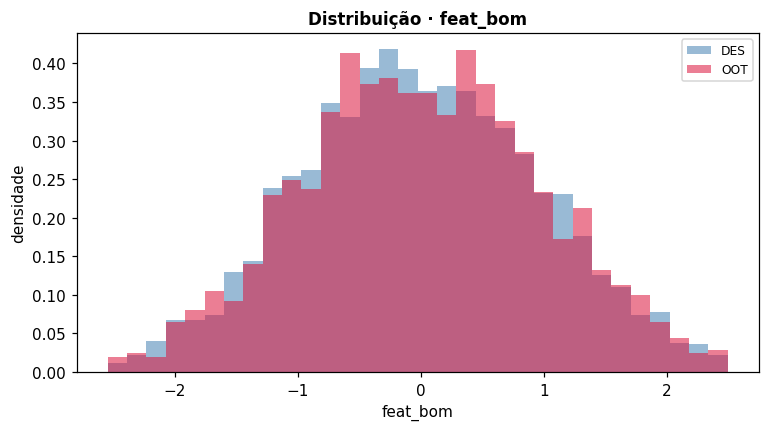

In [7]:
plot_histogram(df, "feat_bom", cfg, ec, "classification")  # DES vs OOT

## 4. Binning + relação com o alvo + WoE/IV (itens 5 e 6)

In [8]:
from yggdrasil.eda import bivariate
tab = bivariate.event_rate_by_bin(df, "feat_bom", cfg, ec, "classification")
print("IV =", round(tab.attrs.get("iv", float("nan")), 4),
      "| monotonicidade:", bivariate.monotonicity_diagnostic(tab))
display(tab)

IV = 5.0664 | monotonicidade: {'trend': 'crescente', 'n_inversoes': 0, 'spearman': 1.0}


,bin,faixa,n,pct,event_rate,woe,iv_parcial,lower_ci,upper_ci
0,01,"(-inf, -1.258]",498,0.0996,0.0020,6.1669,1.1999,0.0004,0.0113
1,02,"(-1.258, -0.8574]",490,0.0980,0.0245,3.6453,0.6657,0.0141,0.0423
2,03,"(-0.8574, -0.546]",510,0.1020,0.0863,2.3207,0.3826,0.0649,0.1138
3,04,"(-0.546, -0.278]",505,0.1010,0.1861,1.4361,0.1765,0.1546,0.2224
4,05,"(-0.278, -0.03518]",482,0.0964,0.3610,0.5318,0.0265,0.3194,0.4048
5,06,"(-0.03518, 0.2409]",498,0.0996,0.5703,-0.3222,0.0103,0.5264,0.6131
6,07,"(0.2409, 0.5248]",515,0.1030,0.7845,-1.3311,0.1614,0.7469,0.8178
7,08,"(0.5248, 0.8499]",506,0.1012,0.8913,-2.1433,0.3481,0.8612,0.9155
8,09,"(0.8499, 1.284]",482,0.0964,0.9834,-4.1207,0.7840,0.9676,0.9916
9,10,"(1.284, inf]",514,0.1028,0.9981,-6.2769,1.3113,0.9891,0.9997


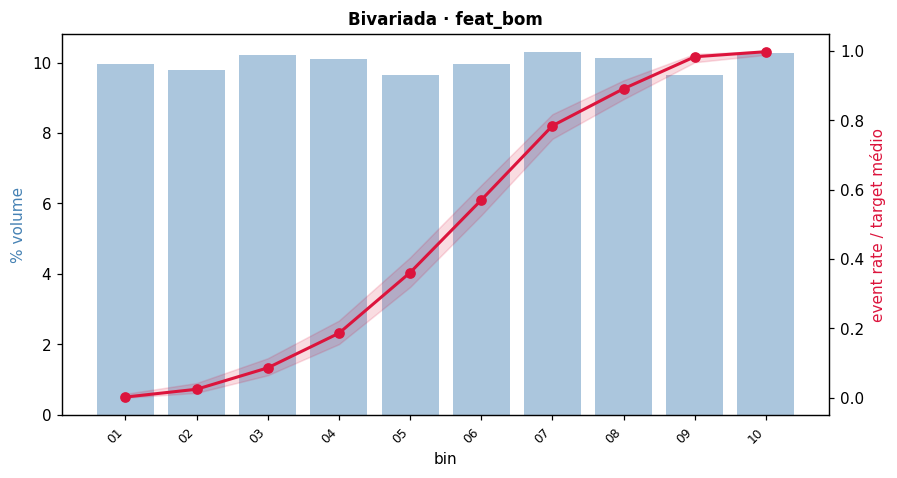

In [9]:
from yggdrasil.eda.plots import plot_bivariate, plot_woe
plot_bivariate(df, "feat_bom", cfg, ec, "classification")

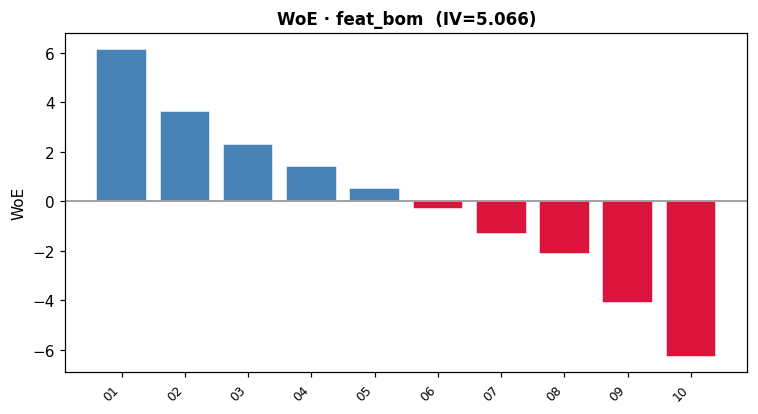

In [10]:
plot_woe(tab, title="WoE · feat_bom")

## 5. Importância (item 7) — univariada + multivariada

In [11]:
from yggdrasil.eda import importance
rk = importance.importance_ranking(df, cfg, ec, "classification")
display(rk)
print("Suspeitas de leakage:", importance.leakage_suspects(rk))

,feature,iv,ks_univ,auc_univ,gini_univ,mutual_info,rf_importance,permutation,score,leakage_flag
0,feat_leakage,22.1258,1.0000,1.0000,1.0000,0.6930,0.7229,0.4999,6.3333,True
1,feat_bom,5.0664,0.7182,0.9380,0.8761,0.3829,0.2586,0.0000,4.9167,True
2,feat_missing,0.0131,0.0720,0.5294,0.0587,0.0000,0.0052,0.0000,3.3333,False
3,feat_instavel,0.0079,0.0210,0.5057,0.0113,0.0000,0.0062,0.0000,3.1667,False
4,feat_cat,0.0028,NaN,NaN,NaN,0.0004,0.0010,0.0000,3.1250,False
5,feat_fraca,0.0035,0.0152,0.5034,0.0068,0.0000,0.0060,0.0000,2.5000,False
6,feat_const,0.0000,NaN,NaN,NaN,0.0000,0.0000,0.0000,2.0000,False


Suspeitas de leakage: ['feat_leakage', 'feat_bom']


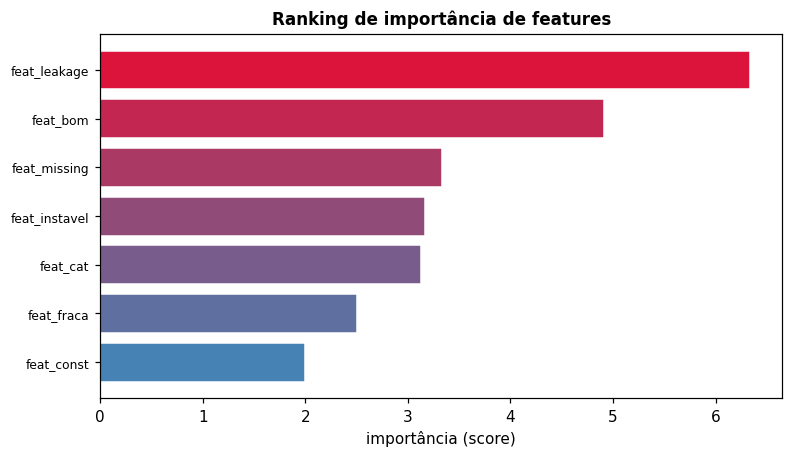

In [12]:
from yggdrasil.eda.plots import plot_importance_ranking
plot_importance_ranking(rk)

## 6. Estabilidade — PSI por feature (item 8)

In [13]:
from yggdrasil.eda import stability
print("Resumo de estabilidade:")
display(stability.stability_summary(df, cfg, ec))

Resumo de estabilidade:


,feature,psi_oot,flag,psi_max_safra
0,feat_bom,0.0064,estavel,0.0333
1,feat_fraca,0.0085,estavel,0.0401
2,feat_cat,0.0060,estavel,0.0144
3,feat_const,0.0000,estavel,0.0000
4,feat_instavel,6.4180,instavel,7.4461
5,feat_missing,0.0350,estavel,0.1401
6,feat_leakage,0.0040,estavel,0.0301


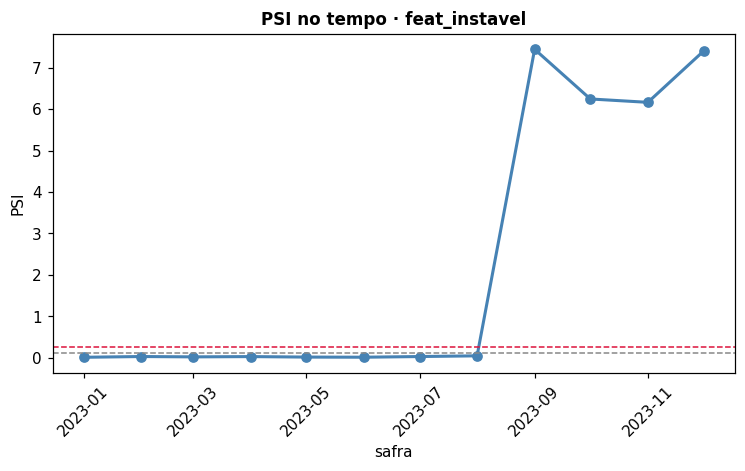

In [14]:
from yggdrasil.eda.plots import plot_feature_psi_over_time
plot_feature_psi_over_time(df, "feat_instavel", cfg, ec)   # PSI explode no OOT

## 7. Correlação e redundância (extra)

In [15]:
from yggdrasil.eda import correlation
display(correlation.vif_table(df, cfg, ec))
display(correlation.redundancy_clusters(df, cfg, ec))

,feature,vif,flag
0,feat_leakage,2.0776,ok
1,feat_bom,2.0767,ok
2,feat_missing,1.0015,ok
3,feat_instavel,1.0004,ok
4,feat_fraca,1.0004,ok


,feature,cluster
0,feat_bom,1
1,feat_leakage,2
2,feat_missing,3
3,feat_instavel,4
4,feat_fraca,5


## 8. Esteira completa: `run_feature_eda`

Roda tudo de uma vez e consolida no `feature_profile` (uma linha por feature, com flags e **veredito**),
mais painéis por feature. Aceita `mlflow_experiment="..."` para logar o resumo + painéis.

In [16]:
from yggdrasil.eda import run_feature_eda
rep = run_feature_eda(df, cfg, ec, with_panels=True)
cols = ["feature", "tipo", "pct_missing", "psi_oot", "iv", "gini_univ", "score", "leakage", "veredito"]
display(rep.feature_profile[cols])

,feature,tipo,pct_missing,psi_oot,iv,gini_univ,score,leakage,veredito
0,feat_leakage,numeric,0.0000,0.0040,22.1258,1.0000,6.3333,True,revisar
1,feat_bom,numeric,0.0000,0.0064,5.0664,0.8761,4.9167,True,revisar
2,feat_missing,numeric,0.6000,0.0350,0.0131,0.0587,3.3333,False,descartar
3,feat_instavel,numeric,0.0000,6.4180,0.0079,0.0113,3.1667,False,descartar
4,feat_cat,categorical,0.0000,0.0060,0.0028,NaN,3.1250,False,revisar
5,feat_fraca,numeric,0.0000,0.0085,0.0035,0.0068,2.5000,False,revisar
6,feat_const,binary,0.0000,0.0000,0.0000,NaN,2.0000,False,descartar


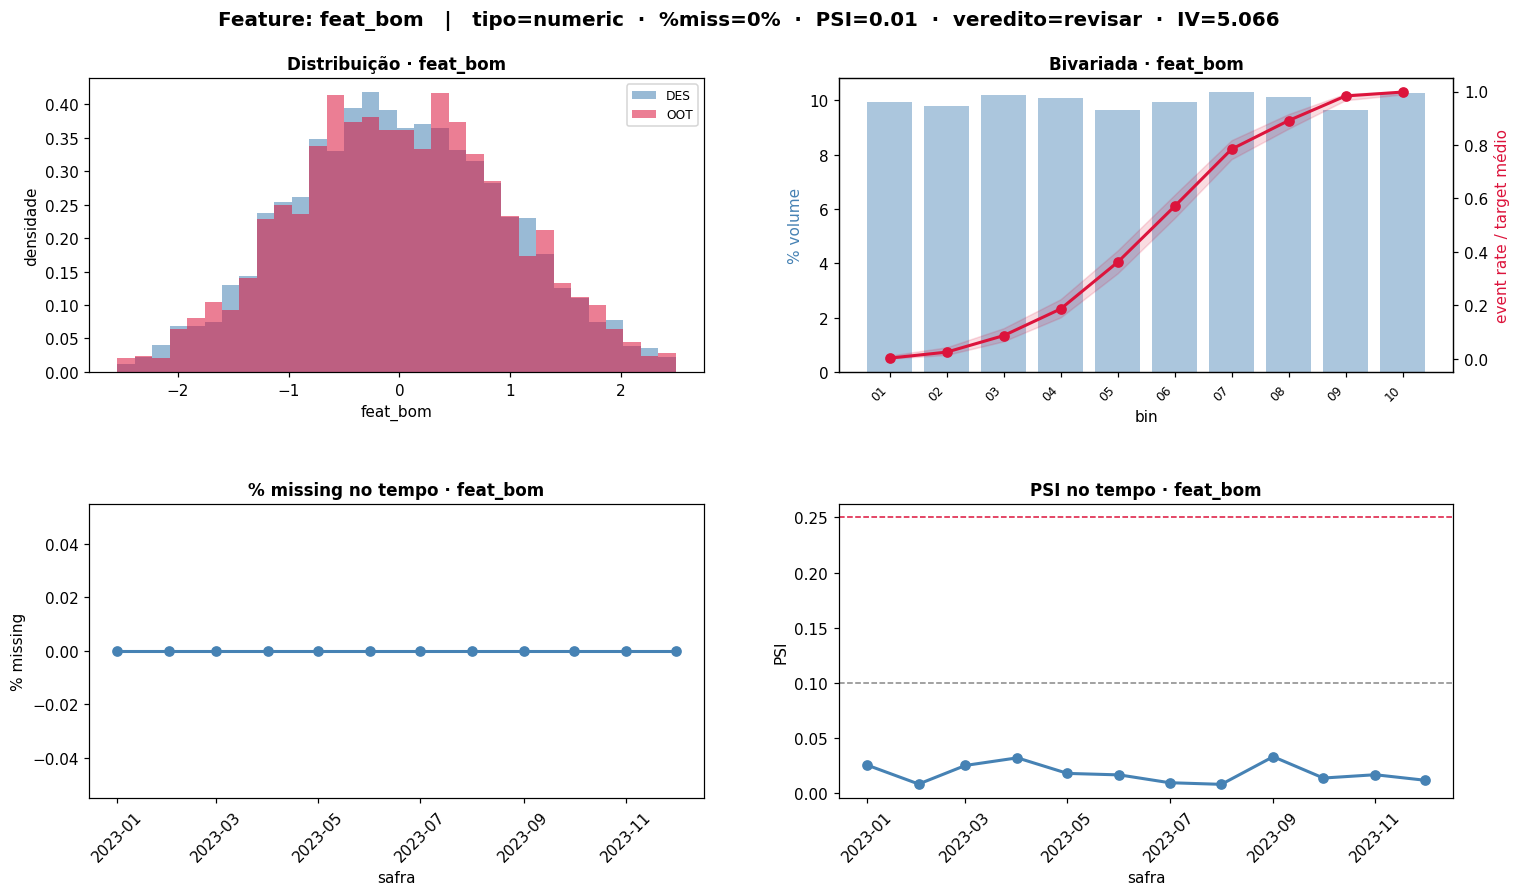

In [17]:
# Painel consolidado de uma feature (distribuição + bivariada + missing/PSI no tempo)
rep.panels["feat_bom"]

## 9. Notas

- **Sem target**: `run_feature_eda` roda mesmo sem `target` — pula só o que depende do alvo (bivariada, WoE/IV, importância) e entrega missing/percentis/PSI/correlação.
- **Sentinelas**: `EDAConfig(missing_codes=DEFAULT_MISSING_CODES)` para tratar -999/'NULL' etc. como missing.
- **MLflow**: `run_feature_eda(..., mlflow_experiment="feature_eda")` loga `feature_profile`, HTML e painéis.
- Isolada da esteira de modelo — veja `notebooks/tutoriais/00_tutorial_yggdrasil.ipynb` (PD) e `01_tutorial_lgd.ipynb` (LGD).